# SparseGPでの関数Fitting性能評価: 2次元関数 f₁(x) = ||z||² + f_opt

本notebookでは、画像に示された2次元関数の近似性能を評価します。

## 目標関数
- $f_1(\mathbf{x}) = \|\mathbf{z}\|^2 + f_{\text{opt}}$
- $\mathbf{z} = \mathbf{x} - \mathbf{x}^{\text{opt}}$
- $\mathbf{x}^{\text{opt}} = [0.5, 0.3]$ (固定値)
- $f_{\text{opt}} = -10.0$ (固定値)

## 1. ライブラリのインポートと初期設定

In [ ]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import random
import sys
import time

sys.path.append("../../")
import gpytorch
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# 再現性のための乱数シード設定
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
print("ライブラリのインポートと初期設定完了")

ライブラリのインポートと初期設定完了


## 2. 目標関数の定義とデータセット作成

In [ ]:
# 目標関数の定義: f₁(x) = ||z||² + f_opt
# z = x - x_opt

# 固定パラメータ
x_opt = np.array([0.5, 0.3])  # 最適解位置
f_opt = -10.0  # 最適値


def target_function(x):
    """
    目標関数: f₁(x) = ||z||² + f_opt
    Args:
        x: 入力ベクトル (N, 2) または (2,)
    Returns:
        関数値 (N,) または スカラー
    """
    x = np.array(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # z = x - x_opt
    z = x - x_opt.reshape(1, -1)

    # ||z||²の計算
    z_squared_norm = np.sum(z**2, axis=1)

    # f₁(x) = ||z||² + f_opt
    result = z_squared_norm + f_opt

    return result if len(result) > 1 else result[0]


# 動作確認
print("目標関数のテスト:")
print(f"x_opt = {x_opt}")
print(f"f_opt = {f_opt}")
print(f"f(x_opt) = {target_function(x_opt):.6f} (should be {f_opt})")
print(f"f([0, 0]) = {target_function([0, 0]):.6f}")
print(f"f([1, 1]) = {target_function([1, 1]):.6f}")

目標関数のテスト:
x_opt = [0.5 0.3]
f_opt = -10.0
f(x_opt) = -10.000000 (should be -10.0)
f([0, 0]) = -9.660000
f([1, 1]) = -9.260000


In [ ]:
# データセットの作成
num_samples = 1000
input_range = [-2, 2]  # 入力範囲

# 2次元入力点をランダムサンプリング
X = np.random.uniform(input_range[0], input_range[1], (num_samples, 2))

# 目標関数値を計算
y = target_function(X)

# PyTorchテンソルに変換
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# データ分割（学習:検証:テスト = 7:1.5:1.5）
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データセット作成
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# データローダー作成
batch_size = 64
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    worker_init_fn=worker_init_fn,
    generator=generator,
)

print(f"データセット作成完了:")
print(f"  学習データ: {len(train_dataset)} samples")
print(f"  検証データ: {len(val_dataset)} samples")
print(f"  テストデータ: {len(test_dataset)} samples")
print(f"  入力次元: {X_train.shape[1]}")
print(f"  関数値範囲: [{y.min():.3f}, {y.max():.3f}]")

データセット作成完了:
  学習データ: 700 samples
  検証データ: 150 samples
  テストデータ: 150 samples
  入力次元: 2
  関数値範囲: [-9.993, 0.403]


/var/folders/sh/nky4c839309dmt8714wl6msr0000gn/T/ipykernel_40301/3877869303.py:58: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/sh/nky4c839309dmt8714wl6msr0000gn/T/ipykernel_40301/3877869303.py:58: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


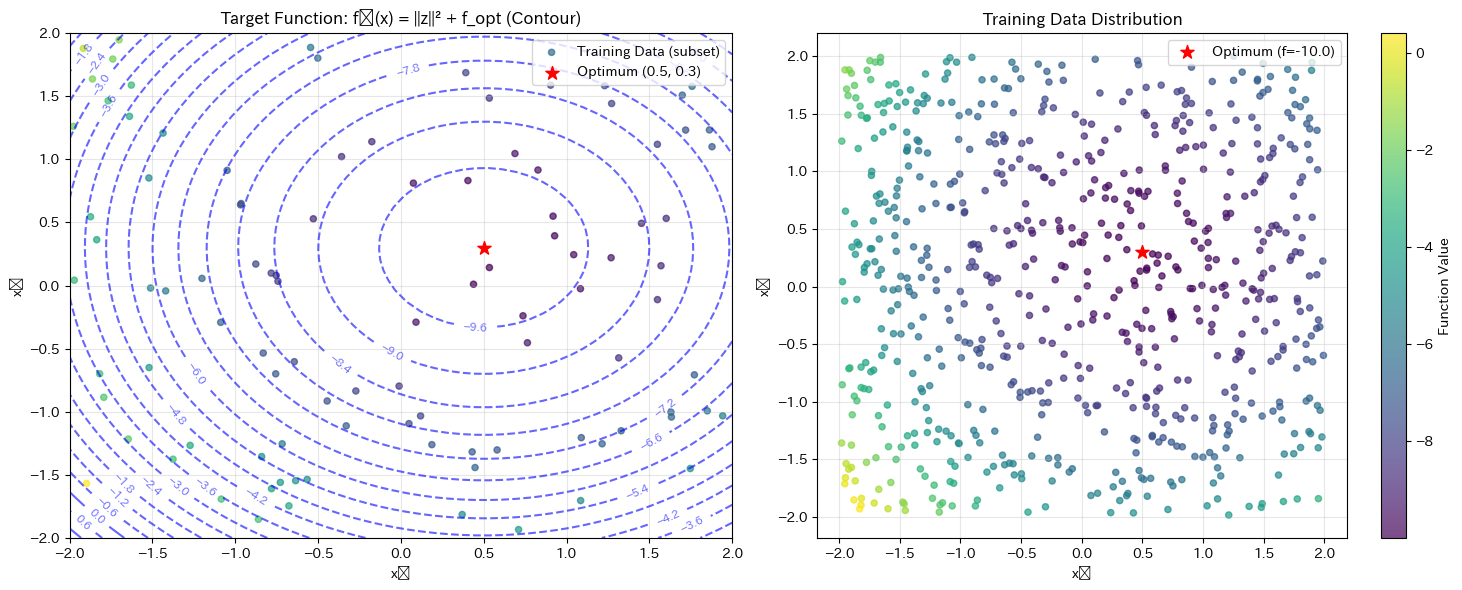

最適解での関数値: f(x_opt) = -10.000000
データの統計:
  平均: -6.905
  標準偏差: 2.292
  最小値: -9.993
  最大値: 0.403


In [ ]:
# 関数の可視化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 3D表面プロット用のグリッド作成
x1_grid = np.linspace(input_range[0], input_range[1], 50)
x2_grid = np.linspace(input_range[0], input_range[1], 50)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
Z_grid = target_function(grid_points).reshape(X1_grid.shape)

# 左: 等高線プロット
contour = axes[0].contour(X1_grid, X2_grid, Z_grid, levels=20, colors="blue", alpha=0.6)
axes[0].clabel(contour, inline=True, fontsize=8)
axes[0].scatter(
    X_train[:100, 0],
    X_train[:100, 1],
    c=y_train[:100],
    cmap="viridis",
    s=20,
    alpha=0.7,
    label="Training Data (subset)",
)
axes[0].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum ({x_opt[0]}, {x_opt[1]})",
    zorder=5,
)
axes[0].set_xlabel("x₁")
axes[0].set_ylabel("x₂")
axes[0].set_title("Target Function: f₁(x) = ||z||² + f_opt (Contour)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右: 散布図（関数値の分布）
scatter = axes[1].scatter(
    X_train[:, 0], X_train[:, 1], c=y_train.numpy(), cmap="viridis", s=20, alpha=0.7
)
axes[1].scatter(
    x_opt[0],
    x_opt[1],
    c="red",
    s=100,
    marker="*",
    label=f"Optimum (f={f_opt})",
    zorder=5,
)
plt.colorbar(scatter, ax=axes[1], label="Function Value")
axes[1].set_xlabel("x₁")
axes[1].set_ylabel("x₂")
axes[1].set_title("Training Data Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最適解での関数値: f(x_opt) = {target_function(x_opt):.6f}")
print(f"データの統計:")
print(f"  平均: {y.mean():.3f}")
print(f"  標準偏差: {y.std():.3f}")
print(f"  最小値: {y.min():.3f}")
print(f"  最大値: {y.max():.3f}")

## 3. Sparse Variational GPモデルの実装

In [5]:
# Sparse Variational GPモデルの定義（2次元入力対応）
class SparseVariationalGP2D(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points):
        # 変分分布の設定
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(0)
        )
        # 変分戦略の設定（誘導点の学習を有効化）
        variational_strategy = gpytorch.variational.VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        super(SparseVariationalGP2D, self).__init__(variational_strategy)

        # 平均関数（定数平均）
        self.mean_module = gpytorch.means.ConstantMean()

        # 共分散関数（ARDカーネル：各次元で異なるlengthscale）
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=2)  # 2次元入力用
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# 誘導点の初期化（2次元グリッド）
num_inducing = 16  # 4x4グリッド
inducing_grid_1d = torch.linspace(-1, 1, 4)
inducing_grid_x1, inducing_grid_x2 = torch.meshgrid(
    inducing_grid_1d, inducing_grid_1d, indexing="ij"
)
inducing_points = torch.stack(
    [inducing_grid_x1.flatten(), inducing_grid_x2.flatten()], dim=1
)

print(f"誘導点の初期化:")
print(f"  誘導点数: {num_inducing}")
print(f"  誘導点の形状: {inducing_points.shape}")
print(
    f"  誘導点の範囲: x1=[{inducing_points[:, 0].min():.2f}, {inducing_points[:, 0].max():.2f}], x2=[{inducing_points[:, 1].min():.2f}, {inducing_points[:, 1].max():.2f}]"
)

# モデルとlikelihoodの作成
model_2d = SparseVariationalGP2D(inducing_points)
likelihood_2d = gpytorch.likelihoods.GaussianLikelihood()

print("2次元Sparse Variational GPモデル作成完了")

誘導点の初期化:
  誘導点数: 16
  誘導点の形状: torch.Size([16, 2])
  誘導点の範囲: x1=[-1.00, 1.00], x2=[-1.00, 1.00]
2次元Sparse Variational GPモデル作成完了


## 4. モデルの学習

/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


学習開始...
Epoch 50/200
  Train Loss: 17.4226
  Val Loss: 17.7312
Epoch 100/200
  Train Loss: 5.3744
  Val Loss: 5.4344
Epoch 150/200
  Train Loss: 1.7037
  Val Loss: 1.6928
Epoch 200/200
  Train Loss: 1.2190
  Val Loss: 1.1989
学習完了!
学習時間: 10.20秒


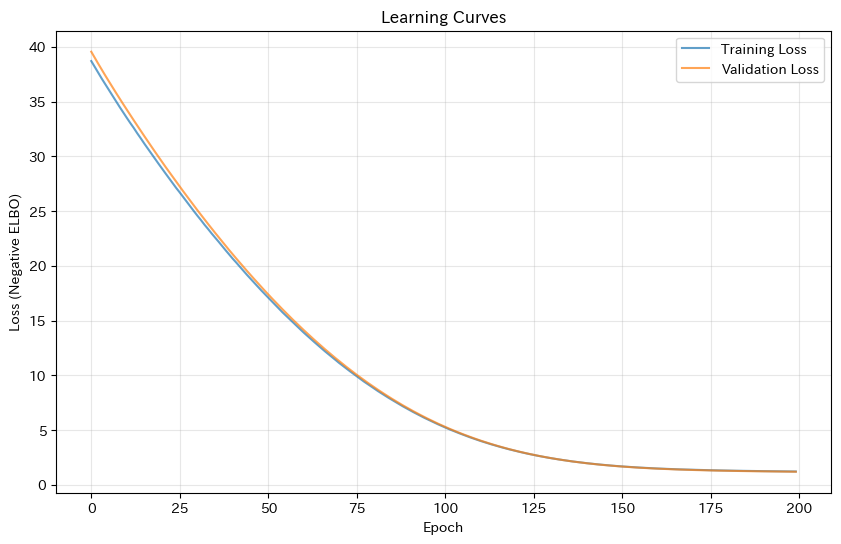

In [ ]:
# モデルの学習
model_2d.train()
likelihood_2d.train()

# オプティマイザとスケジューラの設定
optimizer = torch.optim.Adam(
    [
        {"params": model_2d.parameters()},
        {"params": likelihood_2d.parameters()},
    ],
    lr=0.001,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.8, patience=20, verbose=True
)

# 変分下界（ELBO）損失関数
mll = gpytorch.mlls.VariationalELBO(
    likelihood_2d, model_2d, num_data=len(train_dataset)
)

# 学習ループ
num_epochs = 200
train_losses = []
val_losses = []

print("学習開始...")
start_time = time.time()

for epoch in range(num_epochs):
    # 学習フェーズ
    model_2d.train()
    likelihood_2d.train()
    epoch_train_loss = 0.0

    for x_batch, y_batch in train_dataloader:
        optimizer.zero_grad()
        output = model_2d(x_batch)
        loss = -mll(output, y_batch.squeeze())
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)

    # 検証フェーズ
    model_2d.eval()
    likelihood_2d.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for x_batch, y_batch in val_dataloader:
            output = model_2d(x_batch)
            loss = -mll(output, y_batch.squeeze())
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    # スケジューラのステップ
    scheduler.step(avg_val_loss)

    # 進捗表示
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"  Train Loss: {avg_train_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")

end_time = time.time()
training_time = end_time - start_time

print(f"学習完了!")
print(f"学習時間: {training_time:.2f}秒")

# 学習曲線の表示
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", alpha=0.7)
plt.plot(val_losses, label="Validation Loss", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss (Negative ELBO)")
plt.title("Learning Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. モデルの評価

In [ ]:
# モデルの評価
model_2d.eval()
likelihood_2d.eval()

# テストデータでの予測
with torch.no_grad():
    test_predictions = likelihood_2d(model_2d(X_test))
    test_mean = test_predictions.mean
    test_var = test_predictions.variance
    test_lower, test_upper = test_predictions.confidence_region()

# 評価指標の計算
test_rmse = torch.sqrt(torch.mean((test_mean - y_test.squeeze()) ** 2))
test_mae = torch.mean(torch.abs(test_mean - y_test.squeeze()))
test_r2 = 1 - torch.sum((y_test.squeeze() - test_mean) ** 2) / torch.sum(
    (y_test.squeeze() - y_test.mean()) ** 2
)

print("=== テスト性能 ===")
print(f"RMSE: {test_rmse.item():.6f}")
print(f"MAE: {test_mae.item():.6f}")
print(f"R²: {test_r2.item():.6f}")
print(f"平均予測分散: {test_var.mean().item():.6f}")

# 学習されたハイパーパラメータの表示
print("\n=== 学習されたハイパーパラメータ ===")
print(f"観測ノイズ: {likelihood_2d.noise.item():.6f}")
print(f"出力スケール: {model_2d.covar_module.outputscale.item():.6f}")
print(
    f"Length scales: {model_2d.covar_module.base_kernel.lengthscale.detach().numpy()}"
)
print(f"平均関数定数: {model_2d.mean_module.constant.item():.6f}")

# 誘導点の最終位置
final_inducing_points = model_2d.variational_strategy.inducing_points.detach().numpy()
print(f"\n誘導点の移動:")
print(
    f"  初期範囲: x1=[{inducing_points[:, 0].min():.2f}, {inducing_points[:, 0].max():.2f}], x2=[{inducing_points[:, 1].min():.2f}, {inducing_points[:, 1].max():.2f}]"
)
print(
    f"  最終範囲: x1=[{final_inducing_points[:, 0].min():.2f}, {final_inducing_points[:, 0].max():.2f}], x2=[{final_inducing_points[:, 1].min():.2f}, {final_inducing_points[:, 1].max():.2f}]"
)

=== テスト性能 ===
RMSE: 0.642847
MAE: 0.521944
R²: 0.926270
平均予測分散: 1.137498

=== 学習されたハイパーパラメータ ===
観測ノイズ: 1.102298
出力スケール: 2.191281
Length scales: [[1.6984999 1.9137597]]
平均関数定数: -1.051708

誘導点の移動:
  初期範囲: x1=[-1.00, 1.00], x2=[-1.00, 1.00]
  最終範囲: x1=[-1.81, 1.79], x2=[-2.26, 1.63]


## 6. 結果の可視化

/var/folders/sh/nky4c839309dmt8714wl6msr0000gn/T/ipykernel_40301/1511372027.py:133: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/sh/nky4c839309dmt8714wl6msr0000gn/T/ipykernel_40301/1511372027.py:133: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


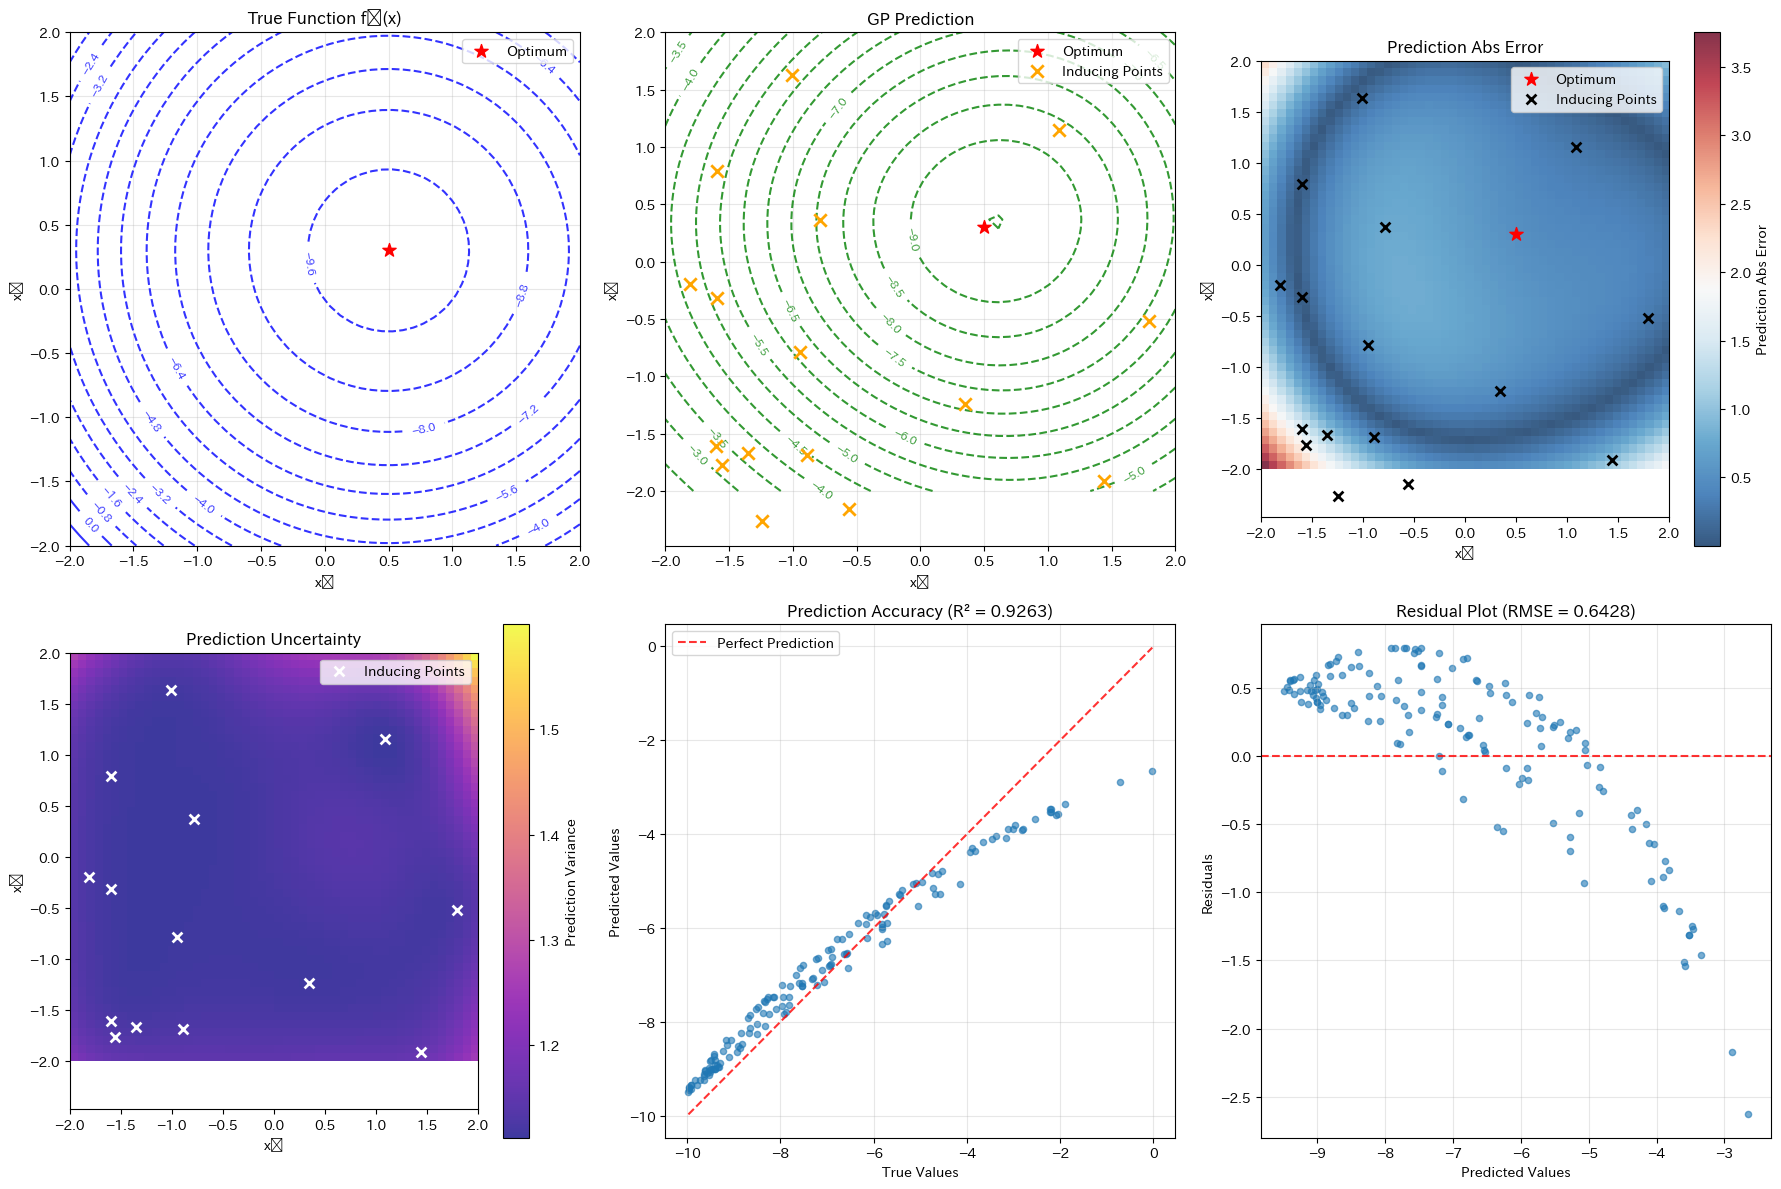

=== 近似性能サマリー ===
目標関数: f₁(x) = ||x - x_opt||² + f_opt
  x_opt = [0.5 0.3]
  f_opt = -10.0
学習データ数: 700
テストRMSE: 0.642847
テストR²: 0.926270
誘導点数: 16
学習時間: 10.20秒


In [ ]:
# 予測結果の可視化
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 密なグリッドでの予測（可視化用）
grid_density = 50
x1_dense = np.linspace(input_range[0], input_range[1], grid_density)
x2_dense = np.linspace(input_range[0], input_range[1], grid_density)
X1_dense, X2_dense = np.meshgrid(x1_dense, x2_dense)
grid_dense = torch.FloatTensor(np.column_stack([X1_dense.ravel(), X2_dense.ravel()]))

# 密なグリッドでの予測
with torch.no_grad():
    dense_predictions = likelihood_2d(model_2d(grid_dense))
    dense_mean = dense_predictions.mean.reshape(grid_density, grid_density)
    dense_var = dense_predictions.variance.reshape(grid_density, grid_density)

# 真の関数値（密なグリッド）
true_dense = target_function(grid_dense.numpy()).reshape(grid_density, grid_density)

# 1. 真の関数（等高線）
contour1 = axes[0, 0].contour(
    X1_dense, X2_dense, true_dense, levels=15, colors="blue", alpha=0.8
)
axes[0, 0].clabel(contour1, inline=True, fontsize=8)
axes[0, 0].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
axes[0, 0].set_title("True Function f₁(x)")
axes[0, 0].set_xlabel("x₁")
axes[0, 0].set_ylabel("x₂")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. GP予測（等高線）
contour2 = axes[0, 1].contour(
    X1_dense, X2_dense, dense_mean.numpy(), levels=15, colors="green", alpha=0.8
)
axes[0, 1].clabel(contour2, inline=True, fontsize=8)
axes[0, 1].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
# 誘導点をプロット
axes[0, 1].scatter(
    final_inducing_points[:, 0],
    final_inducing_points[:, 1],
    c="orange",
    s=80,
    marker="x",
    linewidths=2,
    label="Inducing Points",
    zorder=5,
)
axes[0, 1].set_title("GP Prediction")
axes[0, 1].set_xlabel("x₁")
axes[0, 1].set_ylabel("x₂")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. 予測誤差
error_dense = np.abs(dense_mean.numpy() - true_dense)
im1 = axes[0, 2].imshow(
    error_dense,
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="RdBu_r",
    alpha=0.8,
)
axes[0, 2].scatter(
    x_opt[0], x_opt[1], c="red", s=100, marker="*", label="Optimum", zorder=5
)
axes[0, 2].scatter(
    final_inducing_points[:, 0],
    final_inducing_points[:, 1],
    c="black",
    s=50,
    marker="x",
    linewidths=2,
    label="Inducing Points",
    zorder=5,
)
plt.colorbar(im1, ax=axes[0, 2], label="Prediction Abs Error")
axes[0, 2].set_title("Prediction Abs Error")
axes[0, 2].set_xlabel("x₁")
axes[0, 2].set_ylabel("x₂")
axes[0, 2].legend()

# 4. 予測不確実性（分散）
im2 = axes[1, 0].imshow(
    dense_var.numpy(),
    extent=[input_range[0], input_range[1], input_range[0], input_range[1]],
    origin="lower",
    cmap="plasma",
    alpha=0.8,
)
axes[1, 0].scatter(
    final_inducing_points[:, 0],
    final_inducing_points[:, 1],
    c="white",
    s=50,
    marker="x",
    linewidths=2,
    label="Inducing Points",
    zorder=5,
)
plt.colorbar(im2, ax=axes[1, 0], label="Prediction Variance")
axes[1, 0].set_title("Prediction Uncertainty")
axes[1, 0].set_xlabel("x₁")
axes[1, 0].set_ylabel("x₂")
axes[1, 0].legend()

# 5. 散布図：真の値 vs 予測値（テストデータ）
axes[1, 1].scatter(y_test.numpy(), test_mean.numpy(), alpha=0.6, s=20)
min_val = min(y_test.min().item(), test_mean.min().item())
max_val = max(y_test.max().item(), test_mean.max().item())
axes[1, 1].plot(
    [min_val, max_val], [min_val, max_val], "r--", alpha=0.8, label="Perfect Prediction"
)
axes[1, 1].set_xlabel("True Values")
axes[1, 1].set_ylabel("Predicted Values")
axes[1, 1].set_title(f"Prediction Accuracy (R² = {test_r2.item():.4f})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. 残差プロット
residuals = (test_mean - y_test.squeeze()).numpy()
axes[1, 2].scatter(test_mean.numpy(), residuals, alpha=0.6, s=20)
axes[1, 2].axhline(y=0, color="r", linestyle="--", alpha=0.8)
axes[1, 2].set_xlabel("Predicted Values")
axes[1, 2].set_ylabel("Residuals")
axes[1, 2].set_title(f"Residual Plot (RMSE = {test_rmse.item():.4f})")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 統計サマリー
print("=== 近似性能サマリー ===")
print(f"目標関数: f₁(x) = ||x - x_opt||² + f_opt")
print(f"  x_opt = {x_opt}")
print(f"  f_opt = {f_opt}")
print(f"学習データ数: {len(train_dataset)}")
print(f"テストRMSE: {test_rmse.item():.6f}")
print(f"テストR²: {test_r2.item():.6f}")
print(f"誘導点数: {len(final_inducing_points)}")
print(f"学習時間: {training_time:.2f}秒")